In [2]:
import pandas as pd
df = pd.read_csv("/content/2025-08-28_filtered_data.csv")
df

,Unix_Timestamp,Topic,Target Weight (41977),C1 (Each Pack Grammage Vlaue) (30183),Production Speed (31790),Actual Speed,target_Speed,Actual Count,DF 1 Weight (30461),IF 1 Weight (30463),...,RF 4 Time (40791),RF 5 Time (40792),RF 6 Time (40793),RF 7 Time (40794),RF 8 Time (40795),RF 9 Time (40796),DF 1 Weight (30461).1,IF 1 Weight (30463).1,DF 1 Weight (Constant) (41981).1,IF 1 Weight (Constant) (41984).1
0,8/28/2025 3:36,weigher10_c2,20,19.916854,34.7,59.7,80,179,278,537,...,31,32,31,29,31,0,278,537,235,300
1,8/28/2025 3:39,weigher10_c2,20,20.007263,35.0,80.7,80,242,332,396,...,31,32,31,29,31,0,332,396,240,300
2,8/28/2025 3:42,weigher10_c2,20,20.012290,35.4,79.7,80,239,277,744,...,31,32,31,29,31,0,277,744,240,300
3,8/28/2025 3:54,weigher10_c2,20,19.849721,34.8,39.3,80,118,244,520,...,31,32,31,29,31,0,244,520,240,300
4,8/28/2025 3:57,weigher10_c2,20,19.812290,35.1,80.0,80,240,238,393,...,31,32,31,29,31,0,238,393,240,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4632,8/28/2025 22:00,weigher9_c1,20,19.242458,23.4,80.0,80,240,176,120,...,25,25,25,25,24,31,176,120,210,300
4633,8/28/2025 22:03,weigher9_c1,20,13.749162,23.7,80.0,80,240,13,10,...,25,25,25,25,24,31,13,10,210,300
4634,8/28/2025 23:06,weigher9_c1,20,19.066854,20.4,38.0,80,114,205,392,...,25,25,25,25,24,31,205,392,210,300
4635,8/28/2025 23:09,weigher9_c1,20,16.567598,20.7,80.0,80,240,281,270,...,25,25,25,25,24,31,281,270,210,300


In [3]:
pd.set_option("display.max_rows", 58)
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 1000)
print(df.head(5))


   Unix_Timestamp         Topic  Target Weight (41977)  C1 (Each Pack Grammage Vlaue) (30183)  Production Speed (31790)  ...  RF 9 Time (40796)  DF 1 Weight (30461).1  IF 1 Weight (30463).1  DF 1 Weight (Constant) (41981).1  IF 1 Weight (Constant) (41984).1
0  8/28/2025 3:36  weigher10_c2                     20                              19.916854                      34.7  ...                  0                    278                    537                               235                               300
1  8/28/2025 3:39  weigher10_c2                     20                              20.007263                      35.0  ...                  0                    332                    396                               240                               300
2  8/28/2025 3:42  weigher10_c2                     20                              20.012290                      35.4  ...                  0                    277                    744                               240   

In [4]:
print("desciption of data is as follows: \n ",df.describe())

desciption of data is as follows: 
         Target Weight (41977)  C1 (Each Pack Grammage Vlaue) (30183)  Production Speed (31790)  Actual Speed  target_Speed  ...  RF 9 Time (40796)  DF 1 Weight (30461).1  IF 1 Weight (30463).1  DF 1 Weight (Constant) (41981).1  IF 1 Weight (Constant) (41984).1
count            4637.000000                            4637.000000               4637.000000   4637.000000   4637.000000  ...        4637.000000            4637.000000            4637.000000                       4637.000000                       4637.000000
mean               27.654949                              25.976841                 52.085508     69.395708     74.052189  ...          22.153116             300.877938             414.393142                        272.186759                        331.971102
std                19.069307                              17.933928                 16.193448     16.415506     13.384854  ...          13.340591             109.042156             16

In [5]:
print(df.isnull().sum())

Unix_Timestamp                           0
Topic                                    0
Target Weight (41977)                    0
C1 (Each Pack Grammage Vlaue) (30183)    0
Production Speed (31790)                 0
Actual Speed                             0
target_Speed                             0
Actual Count                             0
DF 1 Weight (30461)                      0
IF 1 Weight (30463)                      0
DF 1 Weight (Constant) (41981)           0
IF 1 Weight (Constant) (41984)           0
proper_count                             0
Proper (34684)                           0
over_wt_count                            0
Over Weight (34686)                      0
under_wt_count                           0
Under Weight (34688)                     0
Total Weight (34711)                     0
Actual Weight                            0
ega_gm                                   0
ega                                      0
Each Pack Grammage Weight                0
Total Radia

In [56]:
# Convert timestamp to pandas datetime
df['Unix_Timestamp'] = pd.to_datetime(df['Unix_Timestamp'], errors='coerce')


# Rename columns
rename_dict = {
"Unix_Timestamp": "timestamp",
"Topic": "topic",
"Target Weight (41977)": "target_weight",
"C1 (Each Pack Grammage Vlaue) (30183)": "pack_grammage",
"Production Speed (31790)": "prod_speed",
"Actual Speed": "actual_speed",
"target_Speed": "target_speed",
"Actual Count": "actual_count",
"DF 1 Weight (30461)": "df1_weight",
"IF 1 Weight (30463)": "if1_weight",
"DF 1 Weight (Constant) (41981)": "df1_weight_const",
"IF 1 Weight (Constant) (41984)": "if1_weight_const",
"proper_count": "proper_count",
"Proper (34684)": "proper",
"over_wt_count": "overweight_count",
"Over Weight (34686)": "overweight",
"under_wt_count": "underweight_count",
"Under Weight (34688)": "underweight",
"Total Weight (34711)": "total_weight",
"Actual Weight": "actual_weight",
"ega_gm": "ega_gm",
"ega": "ega_pct",
"Each Pack Grammage Weight": "pack_grammage_weight",
"Total Radial Feeders Weight": "total_rf_weight",
"RF 1 Weight (30332)": "rf1_weight",
"RF 2 Weight (30334)": "rf2_weight",
"RF 3 Weight (30336)": "rf3_weight",
"RF 4 Weight (30338)": "rf4_weight",
"RF 5 Weight (30340)": "rf5_weight",
"RF 6 Weight (30342)": "rf6_weight",
"RF 7 Weight (30344)": "rf7_weight",
"RF 8 Weight (30346)": "rf8_weight",
"RF 9 Weight (30348)": "rf9_weight",
"DF 1 Amplitude (40665)": "df1_amp",
"IF 1 Amplitude (40666)": "if1_amp",
"DF 1 Time (40675)": "df1_time",
"RF 1 Amplitude (40754)": "rf1_amp",
"RF 2 Amplitude (40755)": "rf2_amp",
"RF 3 Amplitude (40756)": "rf3_amp",
"RF 4 Amplitude (40757)": "rf4_amp",
"RF 5 Amplitude (40758)": "rf5_amp",
"RF 6 Amplitude (40759)": "rf6_amp",
"RF 7 Amplitude (40760)": "rf7_amp",
"RF 8 Amplitude (40761)": "rf8_amp",
"RF 9 Amplitude (40762)": "rf9_amp",
"RF 1 Time (40788)": "rf1_time",
"RF 2 Time (40789)": "rf2_time",
"RF 3 Time (40790)": "rf3_time",
"RF 4 Time (40791)": "rf4_time",
"RF 5 Time (40792)": "rf5_time",
"RF 6 Time (40793)": "rf6_time",
"RF 7 Time (40794)": "rf7_time",
"RF 8 Time (40795)": "rf8_time",
"RF 9 Time (40796)": "rf9_time",
"DF 1 Weight (30461).1": "df1_weight_dup",
"IF 1 Weight (30463).1": "if1_weight_dup",
"DF 1 Weight (Constant) (41981).1": "df1_weight_const_dup",
"IF 1 Weight (Constant) (41984).1": "if1_weight_const_dup"
}
existing_cols = [c for c in df.columns if c in rename_dict]
if existing_cols:
  df.rename(columns=rename_dict, inplace=True)

KeyError: 'Unix_Timestamp'

In [57]:
df

,timestamp,topic,target_weight,pack_grammage,prod_speed,...,df1_weight_const_dup,if1_weight_const_dup,ega_per_pack,ega_total_gm,ega_total_per
0,2025-08-28 03:36:00,weigher10_c2,20,19.916854,34.7,...,235,300,-0.083146,-14.883147,-0.415730
1,2025-08-28 03:39:00,weigher10_c2,20,20.007263,35.0,...,240,300,0.007263,1.757542,0.036313
2,2025-08-28 03:42:00,weigher10_c2,20,20.012290,35.4,...,240,300,0.012290,2.937429,0.061452
3,2025-08-28 03:54:00,weigher10_c2,20,19.849721,34.8,...,240,300,-0.150279,-17.732961,-0.751397
4,2025-08-28 03:57:00,weigher10_c2,20,19.812290,35.1,...,240,300,-0.187710,-45.050280,-0.938548
...,...,...,...,...,...,...,...,...,...,...,...
4632,2025-08-28 22:00:00,weigher9_c1,20,19.242458,23.4,...,210,300,-0.757542,-181.810056,-3.787709
4633,2025-08-28 22:03:00,weigher9_c1,20,13.749162,23.7,...,210,300,-6.250838,-1500.201118,-31.254190
4634,2025-08-28 23:06:00,weigher9_c1,20,19.066854,20.4,...,210,300,-0.933146,-106.378652,-4.665730
4635,2025-08-28 23:09:00,weigher9_c1,20,16.567598,20.7,...,210,300,-3.432402,-823.776535,-17.162011


In [8]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (4637, 58)
Columns: ['timestamp', 'topic', 'target_weight', 'pack_grammage', 'prod_speed', 'actual_speed', 'target_speed', 'actual_count', 'df1_weight', 'if1_weight', 'df1_weight_const', 'if1_weight_const', 'proper_count', 'proper', 'overweight_count', 'overweight', 'underweight_count', 'underweight', 'total_weight', 'actual_weight', 'ega_gm', 'ega_pct', 'pack_grammage_weight', 'total_rf_weight', 'rf1_weight', 'rf2_weight', 'rf3_weight', 'rf4_weight', 'rf5_weight', 'rf6_weight', 'rf7_weight', 'rf8_weight', 'rf9_weight', 'df1_amp', 'if1_amp', 'df1_time', 'rf1_amp', 'rf2_amp', 'rf3_amp', 'rf4_amp', 'rf5_amp', 'rf6_amp', 'rf7_amp', 'rf8_amp', 'rf9_amp', 'rf1_time', 'rf2_time', 'rf3_time', 'rf4_time', 'rf5_time', 'rf6_time', 'rf7_time', 'rf8_time', 'rf9_time', 'df1_weight_dup', 'if1_weight_dup', 'df1_weight_const_dup', 'if1_weight_const_dup']


In [58]:
# Creating EGA
# per-pack difference (actual - target)
df['ega_per_pack'] = df['pack_grammage'] - df['target_weight']


# total giveaway per record (per-pack * count)df
df['ega_total_gm'] = df['ega_per_pack'] * df['actual_count']


# percent giveaway relative to target (per pack)
df['ega_total_per'] = (df['ega_per_pack'] / df['target_weight']) * 100

df

,timestamp,topic,target_weight,pack_grammage,prod_speed,...,df1_weight_const_dup,if1_weight_const_dup,ega_per_pack,ega_total_gm,ega_total_per
0,2025-08-28 03:36:00,weigher10_c2,20,19.916854,34.7,...,235,300,-0.083146,-14.883147,-0.415730
1,2025-08-28 03:39:00,weigher10_c2,20,20.007263,35.0,...,240,300,0.007263,1.757542,0.036313
2,2025-08-28 03:42:00,weigher10_c2,20,20.012290,35.4,...,240,300,0.012290,2.937429,0.061452
3,2025-08-28 03:54:00,weigher10_c2,20,19.849721,34.8,...,240,300,-0.150279,-17.732961,-0.751397
4,2025-08-28 03:57:00,weigher10_c2,20,19.812290,35.1,...,240,300,-0.187710,-45.050280,-0.938548
...,...,...,...,...,...,...,...,...,...,...,...
4632,2025-08-28 22:00:00,weigher9_c1,20,19.242458,23.4,...,210,300,-0.757542,-181.810056,-3.787709
4633,2025-08-28 22:03:00,weigher9_c1,20,13.749162,23.7,...,210,300,-6.250838,-1500.201118,-31.254190
4634,2025-08-28 23:06:00,weigher9_c1,20,19.066854,20.4,...,210,300,-0.933146,-106.378652,-4.665730
4635,2025-08-28 23:09:00,weigher9_c1,20,16.567598,20.7,...,210,300,-3.432402,-823.776535,-17.162011


# EGA PER PACK
### target_weight → The intended weight that should go in the pack.
### if ega per pack is +ve then OVER FILL of packet
if +ver Over fill else if -ve , under fill of packet

#ega total gie away
### number of packs produced in that batch or time interval.
### it gives the absolute grams of giveaway for the batch.

# Compare across pack sizes, detect patterns

In [10]:
#to save plots
import os
os.makedirs("outputs", exist_ok=True)

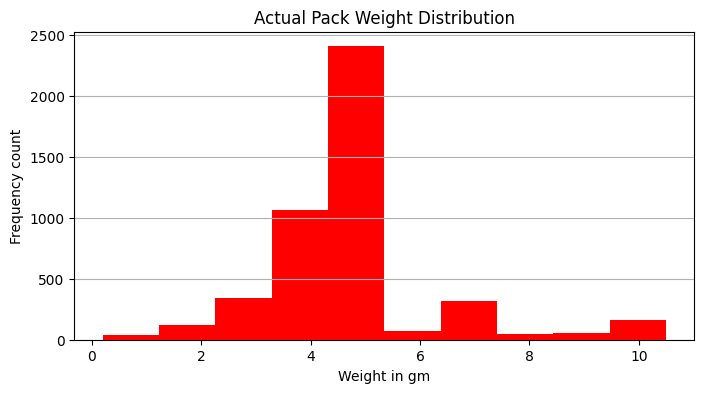

In [11]:
#aactual pack weg
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(df['actual_weight'].dropna(), color='red')
plt.title('Actual Pack Weight Distribution')
plt.xlabel('Weight in gm')
plt.ylabel('Frequency count',#as how pack falls in each weight'
           )
plt.grid(axis='y')
plt.show()

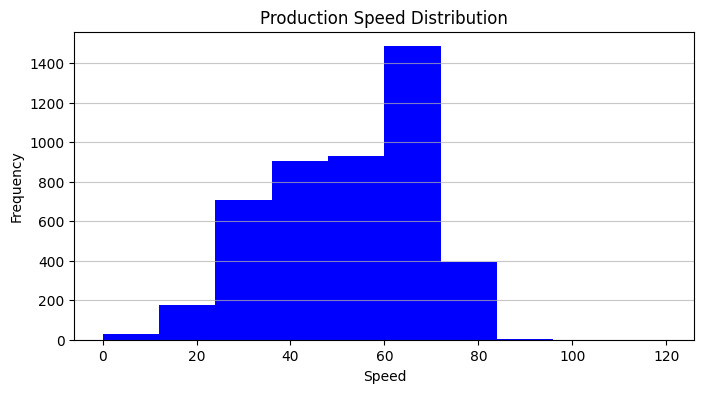

In [12]:
plt.figure(figsize=(8,4))
plt.hist(df['prod_speed'].dropna(), bins=10, color='blue')
plt.title('Production Speed Distribution')
plt.xlabel('Speed')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.7)
plt.show()

In [13]:
print(df[['actual_weight', 'target_weight']].head())

   actual_weight  target_weight
0            3.5             20
1            4.8             20
2            4.8             20
3            2.4             20
4            4.7             20


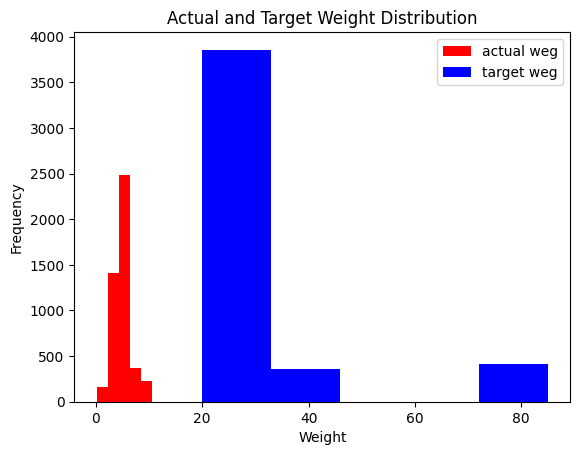

In [14]:
import seaborn as sns
plt.hist(df['actual_weight'], bins=5, color='red')
plt.hist(df['target_weight'], bins=5, color='blue')

plt.title("Actual and Target Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.legend(['actual weg',
            'target weg'])

plt.show()

In [15]:
# over fill
positive_ega = df[df['ega_total_gm'] > 0]
positive_count = positive_ega.shape[0]

# underfill
negative_ega = df[df['ega_total_gm'] < 0]
negative_count = negative_ega.shape[0]

# Zero EGA (exact match=actual)
zero_ega = df[df['ega_total_gm'] == 0]
zero_count = zero_ega.shape[0]

# Print results
print(f"Number of overfilled records (ega_total_gm > 0): {positive_count}")
print(f"Number of underfilled records (ega_total_gm < 0): {negative_count}")
print(f"Number of exact match records (ega_total_gm = 0): {zero_count}")


Number of overfilled records (ega_total_gm > 0): 1793
Number of underfilled records (ega_total_gm < 0): 2833
Number of exact match records (ega_total_gm = 0): 11


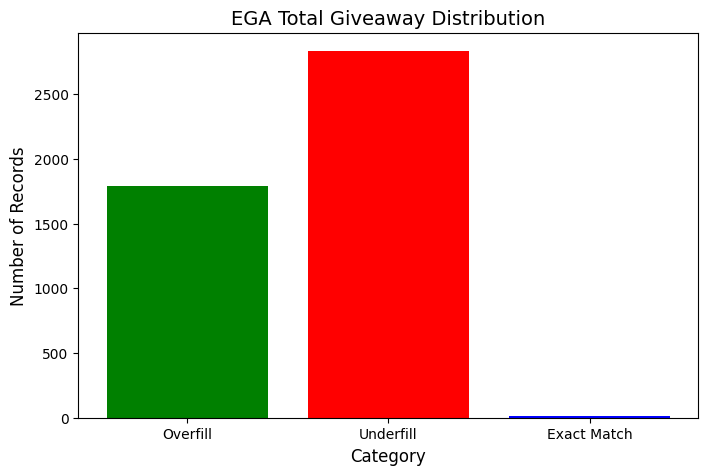

In [59]:
categories = ['Overfill', 'Underfill', 'Exact Match']
counts = [positive_count, negative_count, zero_count]

plt.figure(figsize=(8,5))
plt.bar(categories, counts, color=['green', 'red', 'blue'])
plt.title('EGA Total Giveaway Distribution', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.show()


In [60]:
# Convert Unix_Timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
timestamp_counts = df.groupby('timestamp').size()
print(timestamp_counts)


timestamp
2025-08-28 03:06:00     1
2025-08-28 03:09:00     2
2025-08-28 03:12:00     6
2025-08-28 03:15:00     6
2025-08-28 03:18:00     7
                       ..
2025-08-29 00:18:00     5
2025-08-29 00:21:00    10
2025-08-29 00:24:00    10
2025-08-29 00:27:00    15
2025-08-29 00:30:00    14
Length: 423, dtype: int64


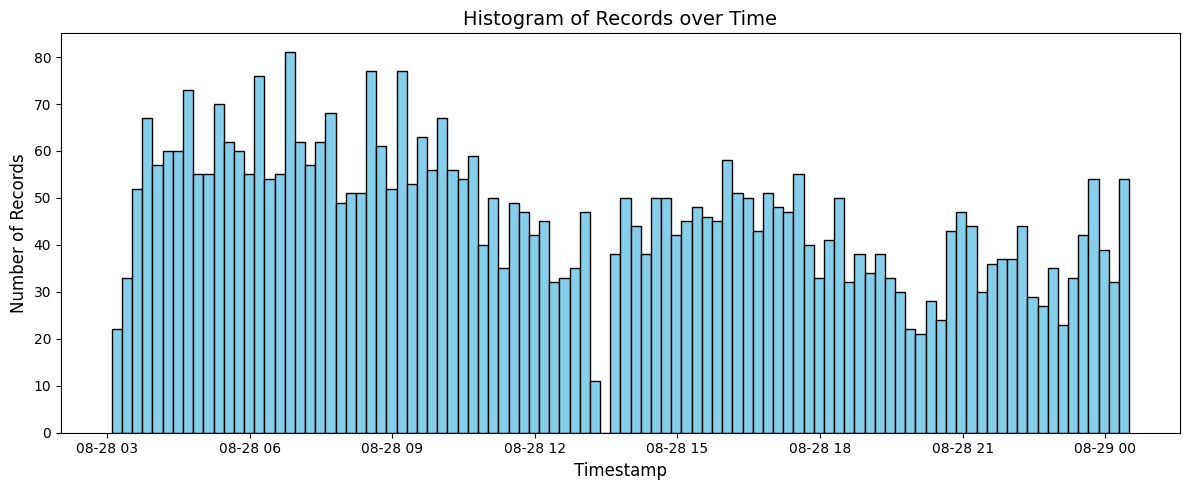

In [61]:
plt.figure(figsize=(12,5))
plt.hist(df['timestamp'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histogram of Records over Time', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.tight_layout()
plt.show()


In [62]:
unique_topics = df['topic'].unique()
print("All unique topics in the dataset:")
print(unique_topics)

topic_counts = df['topic'].value_counts()
print("\nNumber of records per topic:")
print(topic_counts)


All unique topics in the dataset:
['weigher10_c2' 'weigher11_c1' 'weigher12_c2' 'weigher13_c1'
 'weigher14_c2' 'weigher15_c1' 'weigher16_c2' 'weigher17_c1'
 'weigher18_c2' 'weigher19_c1' 'weigher1_c1' 'weigher20_c2' 'weigher2_c2'
 'weigher3_c1' 'weigher4_c2' 'weigher5_c1' 'weigher6_c2' 'weigher7_c1'
 'weigher8_c2' 'weigher9_c1']

Number of records per topic:
topic
weigher13_c1    369
weigher5_c1     343
weigher3_c1     338
weigher18_c2    327
weigher15_c1    322
weigher17_c1    309
weigher7_c1     294
weigher6_c2     293
weigher16_c2    253
weigher12_c2    241
weigher1_c1     214
weigher20_c2    204
weigher14_c2    201
weigher10_c2    182
weigher9_c1     170
weigher8_c2     155
weigher2_c2     153
weigher11_c1    131
weigher19_c1    131
weigher4_c2       7
Name: count, dtype: int64


/tmp/ipython-input-732587744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette="viridis")


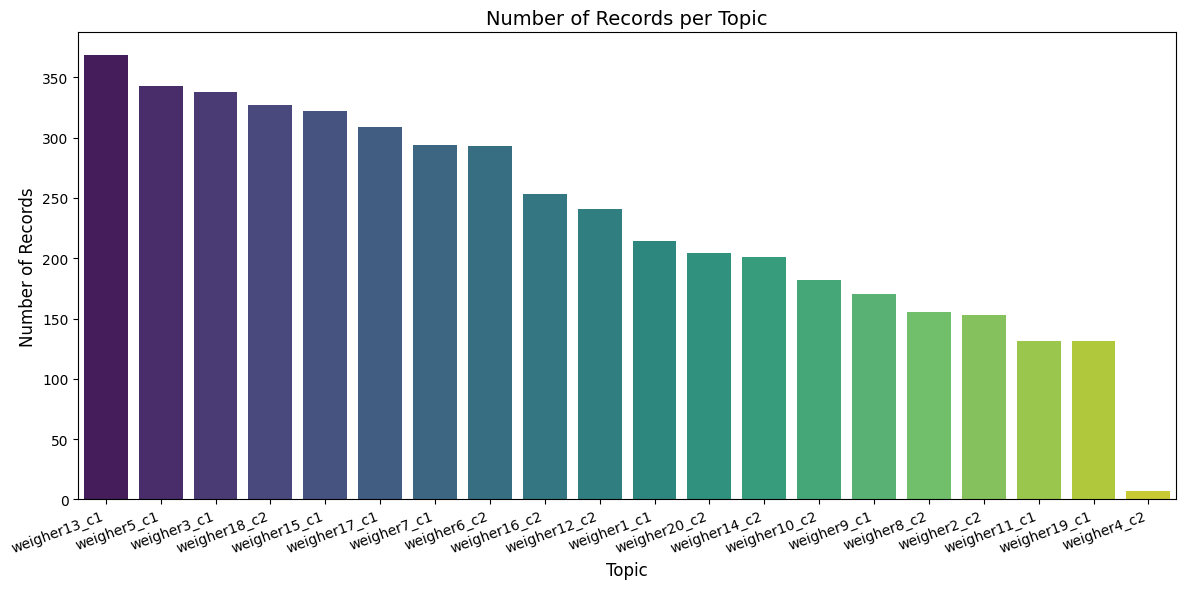

In [64]:
plt.figure(figsize=(12,6))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette="viridis")
plt.title('Number of Records per Topic', fontsize=14)
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


In [21]:
print(df[['underweight_count', 'overweight_count']])

      underweight_count  overweight_count
0                     0                 2
1                     0                 0
2                     0                 0
3                     0                 1
4                     0                 1
...                 ...               ...
4632                  4                 5
4633                 71                 3
4634                 10                 5
4635                 31                 9
4636                 15                 3

[4637 rows x 2 columns]


In [22]:
correlation = df['underweight_count'].corr(df['overweight_count'])
print(f"Correlation between underweight and overweight counts: {correlation}")


Correlation between underweight and overweight counts: -0.06455178447133281


In [23]:
correlation = df['actual_weight'].corr(df['total_weight'])
print(f"Correlation between Actual Weight and Total Weight: {correlation}")


Correlation between Actual Weight and Total Weight: 0.10237015155317168


<Figure size 1400x2000 with 0 Axes>

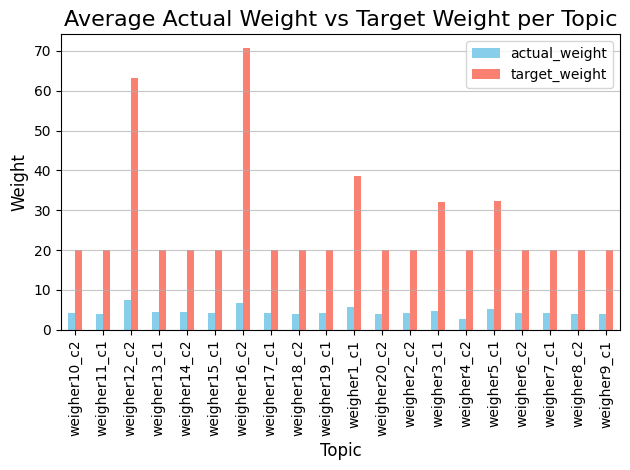

In [28]:
weight_summary = df.groupby('topic')[['actual_weight', 'target_weight']].mean()
plt.figure(figsize=(14,20))
weight_summary.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Actual Weight vs Target Weight per Topic', fontsize=16)
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()


##### Radial Feeders (RF 1–9) → part of the packaging/weighing machine.
#####  Each RF feeds a portion of the product into the packs.
##### Columns like:
#####  RF 1 Weight (30332) → weight contributed by Radial Feeder 1.
#####  RF 1 Amplitude (40754) → vibration amplitude setting for RF1.
##### RF 1 Time (40788) → how long RF1 runs for that pack.

#### Radial Feeders ensure accurate and uniform filling of the product into packs.

#### By analyzing RF columns, you can see which feeder contributes more to overfill or underfill.

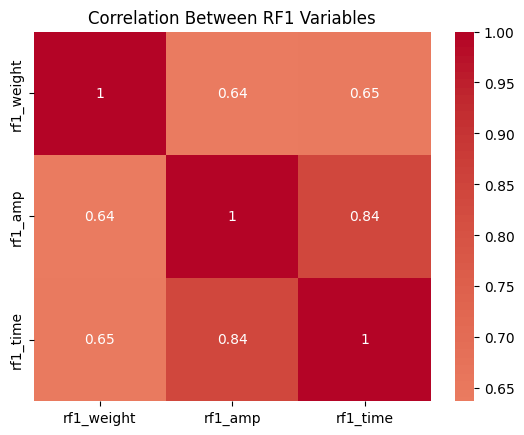

In [42]:
subset = df[["rf1_weight", "rf1_amp", "rf1_time"]]
sns.heatmap(subset.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between RF1 Variables")
plt.show()
